# EDA 12 (v2) — Leaf-level corroboration with Yee & Dennett (2022)

**Purpose.**
EDA 5 compared the *four-way* flow typology (Cascade / Counter / Lateral / Symmetric) against Yee's attribute labels and found a null (Cramér's V ≈ 0.10, ARI ≈ 0.02). Two problems with that test, now resolved:

1. **Pooling.** "Cascade-led" mixed mechanisms that are and are not candidate gentrification. The EDA 9 tree splits it into four measurable leaves; the sharper hypothesis is that Yee's GEN concentrates in specific leaves, not in "cascade" as a whole.
2. **Wrong statistics.** V and ARI on the full contingency table are swamped by Yee's ~71 % Stable base and are meaningless at leaf sample sizes (n = 13–90). **Decision (2026-07-05): V/ARI are retired for the remainder of the study.** We use *enrichment* instead — P(GEN | group) vs the base rate as a lift ratio, with Fisher's exact test on the 2×2 (group vs rest × GEN vs not), which remains exact at any n.

**Design.**
- Mechanism leaves from the EDA 9 time-symmetric tree (identical constants: `INFLOW_MIN = 0.25`, `EXT_MAJ = 0.5`), computed inline so this notebook runs standalone.
- Both census years; both Yee aggregations (`yee_modal` strict, `has_gen` loose, as in EDA 5).
- **Temporal framing (relabelled 2026-07-05).** Yee's labels are built from 2001–2011 attribute
  change, so the two census years answer *different questions* and are reported as such throughout:
  **2011 = concurrent validation** (flows measured in the window the labels describe) and
  **2021 = decade-later persistence test** (does the label–mechanism alignment survive ten years on?).
  The 2021 rows are never read as validating 2021 flows against 2011-era labels — that objection is
  pre-empted by construction. The deck's Findings 1 carries the same two labels.
- **New:** decomposition by Yee's Class-3 gentrification subtypes (SupGen / MainGen / MargGen), which turns out to carry the story.
- Reference groups (Frame-A Counter-led / Lateral / Symmetric) and the genuine-persistent set (inflow-driven in both years) included for contrast.
- Benjamini–Hochberg correction reported across the leaf tests.

**Inputs:** `eda4_results_for_phase3_20260626.csv`, `msoa_cascade_national_frame_20260625.csv`, `LSOA_labels_forMapping.csv`, `lsoa11_to_msoa11.csv`.

In [1]:
# ── setup, inputs, EDA 9 mechanism tree (inline) ─────────────────────────────
import sys
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats
from pyprojroot import here
pd.set_option('display.width', 200)

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / 'data'
OUT_DIR    = ROOT / 'outputs'
FIG_DIR    = OUT_DIR / 'comparison_figs'
NATF       = OUT_DIR / 'msoa_cascade_national_frame_20260625.csv'
EDA4       = OUT_DIR / 'eda4_results_for_phase3_20260626.csv'
YEE_LABELS = DATA_DIR / 'yee_LSOA_labels_forMapping.csv'
LOOKUP     = OUT_DIR / 'lsoa11_to_msoa11.csv'

OUT_DIR.mkdir(parents=True, exist_ok=True)

INFLOW_MIN, EXT_MAJ = 0.25, 0.50   # EDA 9: empirically gapped / stated majority convention
LEAVES = ['inflow-driven', 'frame-sensitive', 'outflow-external', 'outflow-internal']

df = pd.read_csv(EDA4).merge(
    pd.read_csv(NATF)[['msoa11cd', 'Ext_Outflow_nat_11', 'Outflow_Poorer_nat_11',
                       'Ext_Outflow_nat_21', 'Outflow_Poorer_nat_21']], on='msoa11cd')

# MSOA names (e.g. 'Camden 026') so rosters are readable against fig 25 / EDA 10-11 case labels
NAMES = next(p for p in (DATA_DIR / 'MSOA_2011_to_2021_lookup_for_identification.csv',
                         OUT_DIR  / 'MSOA_2011_to_2021_lookup_for_identification.csv') if p.exists())
nm = (pd.read_csv(NAMES, encoding='utf-8-sig')[['MSOA11CD', 'MSOA11NM']].drop_duplicates()
        .rename(columns={'MSOA11CD': 'msoa11cd', 'MSOA11NM': 'msoa_name'}))
df = df.merge(nm, on='msoa11cd', how='left')
assert df['msoa_name'].notna().all(), 'unnamed MSOAs after lookup merge'

# Ext arm share = Ext_Outflow_nat / Outflow_Poorer_nat, defined only above national D6
for yr in ('11', '21'):
    with np.errstate(divide='ignore', invalid='ignore'):
        s = df[f'Ext_Outflow_nat_{yr}'] / df[f'Outflow_Poorer_nat_{yr}']
    df[f'Ext_Arm_Share_{yr}'] = np.where(df['Wealth_Decile_National'] > 6, s.fillna(0), 0.0)

def leaf(r, yr):
    if r[f'Typ_C_{yr}'] != 'Cascade-led':
        return None
    if r[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN:
        return 'inflow-driven' if r[f'Typ_A_{yr}'] == 'Cascade-led' else 'frame-sensitive'
    return 'outflow-external' if r[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ else 'outflow-internal'

for yr in ('11', '21'):
    df[f'leaf_{yr}'] = df.apply(leaf, axis=1, yr=yr)
df['Genuine_Persistent'] = (df['leaf_11'] == 'inflow-driven') & (df['leaf_21'] == 'inflow-driven')

# guard: must reproduce the EDA 9 leaf counts exactly
assert df['leaf_11'].value_counts().to_dict() == {'outflow-internal': 81, 'frame-sensitive': 57,
                                                  'inflow-driven': 56, 'outflow-external': 19}
assert df['leaf_21'].value_counts().to_dict() == {'outflow-internal': 90, 'outflow-external': 78,
                                                  'frame-sensitive': 14, 'inflow-driven': 13}
assert df['Genuine_Persistent'].sum() == 8
print('tree reproduces EDA 9 exactly — 2011:', df.leaf_11.value_counts().to_dict())
print('                              2021:', df.leaf_21.value_counts().to_dict(),
      '| genuine persistent n =', df.Genuine_Persistent.sum())

tree reproduces EDA 9 exactly — 2011: {'outflow-internal': 81, 'frame-sensitive': 57, 'inflow-driven': 56, 'outflow-external': 19}
                              2021: {'outflow-internal': 90, 'outflow-external': 78, 'frame-sensitive': 14, 'inflow-driven': 13} | genuine persistent n = 8


---
## 1. Yee labels → MSOA

Same aggregation as EDA 5, plus the Class-3 subtype flags:

- `yee_modal` — plurality Class-2 label per MSOA (strict; 41 GEN MSOAs).
- `has_gen` — MSOA contains ≥ 1 GEN LSOA (loose; 207 MSOAs).
- `any_SupGen / any_MainGen / any_MargGen` — ***MSOA contains ≥ 1 LSOA of that Class-3 gentrification subtype*** (94 / 39 / 101 MSOAs). Class-3 GEN never wins a plurality at MSOA scale (modal Class-3 GEN n = 0), so the subtype test uses the any-LSOA flag by necessity.

In [2]:
# ── Yee labels: modal, any-GEN, Class-3 subtypes ─────────────────────────────
yee = pd.read_csv(YEE_LABELS).rename(columns={'LSOA_Code': 'lsoa11cd'})
lk  = pd.read_csv(LOOKUP)[['lsoa11cd', 'msoa11cd']].drop_duplicates().dropna()
yg  = yee.merge(lk, on='lsoa11cd', how='inner')
yg  = yg[yg['msoa11cd'].isin(df['msoa11cd'])].copy()
print(f'Yee LSOAs in frame: {len(yg)} across {yg.msoa11cd.nunique()}/{len(df)} MSOAs')

g = yg.groupby('msoa11cd')['Class_2_status']
modal = g.agg(lambda s: s.value_counts().index[0]).rename('yee_modal')
conf  = g.agg(lambda s: s.value_counts().iloc[0] / len(s)).rename('modal_confidence')
has_gen = (yg[yg['Class_2_status'] == 'GEN'].groupby('msoa11cd').size()
           .reindex(modal.index, fill_value=0) > 0).rename('has_gen')
df = df.merge(pd.concat([modal, conf, has_gen], axis=1),
              left_on='msoa11cd', right_index=True, how='left')
df['gen_modal'] = df['yee_modal'] == 'GEN'

for sub in ['SupGen', 'MainGen', 'MargGen']:
    df[f'any_{sub}'] = (yg[yg['Class_3_status'] == sub].groupby('msoa11cd').size()
                        .reindex(df['msoa11cd'], fill_value=0) > 0).values

print('modal GEN:', df.gen_modal.sum(), '| any-GEN:', df.has_gen.sum(),
      '| any-SupGen:', df.any_SupGen.sum(), '| any-MainGen:', df.any_MainGen.sum(),
      '| any-MargGen:', df.any_MargGen.sum())

Yee LSOAs in frame: 4830 across 982/982 MSOAs
modal GEN: 41 | any-GEN: 207 | any-SupGen: 94 | any-MainGen: 39 | any-MargGen: 101


---
## 2. Enrichment test

For a group *g* (a leaf, a reference class, or the persistent set) and a GEN flag:

- **lift** = P(GEN | g) / P(GEN) — 1.0 means no association (statistically independent); >1 enrichment; <1 depletion.
- **Fisher's exact** two-sided p on the 2×2 (in-g vs not × GEN vs not), exact at any n.
- **BH q-value** across the 8 leaf tests per aggregation (two years × four leaves).

In [3]:
# ── enrichment machinery ─────────────────────────────────────────────────────
def enrich(mask, gen, label):
    N, G = len(gen), int(gen.sum())
    n, k = int(mask.sum()), int((mask & gen).sum())
    rate, base = (k / n if n else np.nan), G / N
    OR, p = stats.fisher_exact([[k, n - k], [G - k, N - n - (G - k)]], alternative='two-sided')
    return dict(group=label, n=n, GEN=k, rate_pct=round(rate * 100, 1),
                base_pct=round(base * 100, 1), lift=round(rate / base, 2),
                OR=round(OR, 2), fisher_p=p)

def bh(pvals):
    p = np.asarray(pvals); m = len(p); order = np.argsort(p)
    q = np.empty(m); prev = 1.0
    for rank, i in list(enumerate(order, 1))[::-1]:
        prev = min(prev, p[i] * m / rank); q[i] = prev
    return q

def run_table(gen_col, gen_name):
    rows = []
    for yr in ('11', '21'):
        for lf in LEAVES:
            r = enrich(df[f'leaf_{yr}'] == lf, df[gen_col], lf); r['year'] = f'20{yr}'
            rows.append(r)
    out = pd.DataFrame(rows)
    out['bh_q'] = bh(out['fisher_p'])
    for yr in ('11', '21'):                       # reference groups: no BH (context only)
        for typ in ['Counter-led', 'Lateral', 'Symmetric']:
            r = enrich(df[f'Typ_A_{yr}'] == typ, df[gen_col], f'[ref A] {typ}'); r['year'] = f'20{yr}'
            rows.append(r)
    r = enrich(df['Genuine_Persistent'], df[gen_col], 'genuine-persistent'); r['year'] = 'both'
    rows.append(r)
    out = pd.DataFrame(rows)
    out['bh_q'] = list(bh(out['fisher_p'][:8])) + [np.nan] * (len(out) - 8)
    fmt = lambda v: '' if pd.isna(v) else (f'{v:.4f}' if v >= 1e-4 else f'{v:.1e}')
    out['fisher_p'] = out['fisher_p'].map(fmt); out['bh_q'] = out['bh_q'].map(fmt)
    print(f'===== GEN definition: {gen_name} (base rate {df[gen_col].mean()*100:.1f}%) =====')
    print(out[['year', 'group', 'n', 'GEN', 'rate_pct', 'lift', 'OR', 'fisher_p', 'bh_q']]
          .to_string(index=False)); print()
    return out

tab_modal = run_table('gen_modal', 'yee_modal == GEN (strict)')
tab_any   = run_table('has_gen',   'has_gen — any GEN LSOA (loose)')

===== GEN definition: yee_modal == GEN (strict) (base rate 4.2%) =====
year               group   n  GEN  rate_pct  lift   OR fisher_p   bh_q
2011       inflow-driven  56    2       3.6  0.86 0.84   1.0000 1.0000
2011     frame-sensitive  57    1       1.8  0.42 0.40   0.5074 0.8939
2011    outflow-external  19    1       5.3  1.26 1.28   0.5587 0.8939
2011    outflow-internal  81   12      14.8  3.55 5.23  4.9e-05 0.0004
2021       inflow-driven  13    0       0.0  0.00 0.00   1.0000 1.0000
2021     frame-sensitive  14    0       0.0  0.00 0.00   1.0000 1.0000
2021    outflow-external  78    1       1.3  0.31 0.28   0.2455 0.6547
2021    outflow-internal  90   12      13.3  3.19 4.58   0.0001 0.0006
2011 [ref A] Counter-led 339    3       0.9  0.21 0.14  6.8e-05       
2011     [ref A] Lateral 246   15       6.1  1.46 1.77   0.0966       
2011   [ref A] Symmetric 268   12       4.5  1.07 1.11   0.7242       
2021 [ref A] Counter-led 416    8       1.9  0.46 0.32   0.0021       
2021  

### Reading the main table — the hypothesis is *rejected in an informative way*

Year roles, per the header: **2011 = concurrent validation**, **2021 = decade-later persistence test**.

The pre-registered expectation was that GEN concentrates in **inflow-driven**. ***It does not***:

- **inflow-driven** shows no modal-GEN enrichment in either year (lift 0.86 / 0.00) and only a modest
  loose-GEN signal in the concurrent test (2011: 32.1 % vs 21.1 %, lift 1.52, p = 0.043 — does not
  survive BH). Whatever concurrent signal exists **does not persist** to 2021.
- The strong, BH-robust signal is in **outflow-internal**: modal-GEN lift 3.55 (p = 4.9e-05) in the
  concurrent test **and** 3.19 (p = 1.0e-04) in the persistence test — the *only* cell significant in
  both under the strict aggregation. This alignment validates concurrently *and* persists a decade later.
- **outflow-external (the 2021 exodus class) is GEN-depleted** (loose: lift 0.43, p = 0.0055) — external
  corroboration that the exodus is not gentrification relocating outward.
- **Counter-led is significantly GEN-depleted in both years and both aggregations** — the flow direction
  most anti-associated with attribute gentrification, consistent with EDA 5.
- **genuine-persistent (n = 8)**: 0/8 modal, 2/8 loose. No power at n = 8; also note 2 of the 8 are
  Hillingdon MSOAs (outer, Heathrow-adjacent) — worth a manual sanity check before using this set as
  the flagship exemplar list.

Why would attribute-gentrifying MSOAs sit in the *outflow* branch? The Class-3 subtype decomposition answers this.


In [4]:
# ── Class-3 subtype decomposition: which gentrification is which leaf? ───────
rows = []
for sub in ['SupGen', 'MainGen', 'MargGen']:
    for yr in ('11', '21'):
        for lf in LEAVES:
            r = enrich(df[f'leaf_{yr}'] == lf, df[f'any_{sub}'], lf)
            r.update(year=f'20{yr}', subtype=sub); rows.append(r)
sub_tab = pd.DataFrame(rows)
sub_tab['bh_q'] = np.concatenate([bh(sub_tab.loc[sub_tab.subtype == s, 'fisher_p'])
                                  for s in ['SupGen', 'MainGen', 'MargGen']])
fmt = lambda v: f'{v:.4f}' if v >= 1e-4 else f'{v:.1e}'
for c in ['fisher_p', 'bh_q']: sub_tab[c] = sub_tab[c].map(fmt)
for s in ['SupGen', 'MainGen', 'MargGen']:
    t = sub_tab[sub_tab.subtype == s]
    print(f'===== any_{s} (base {df[f"any_{s}"].mean()*100:.1f}%, {df[f"any_{s}"].sum()} MSOAs) =====')
    print(t[['year', 'group', 'n', 'GEN', 'rate_pct', 'lift', 'OR', 'fisher_p', 'bh_q']]
          .to_string(index=False)); print()

===== any_SupGen (base 9.6%, 94 MSOAs) =====
year            group  n  GEN  rate_pct  lift   OR fisher_p    bh_q
2011    inflow-driven 56    9      16.1  1.68 1.89   0.0995  0.1995
2011  frame-sensitive 57    6      10.5  1.10 1.12   0.8155  0.9320
2011 outflow-external 19    4      21.1  2.20 2.59   0.0998  0.1995
2011 outflow-internal 81   18      22.2  2.32 3.10   0.0005  0.0019
2021    inflow-driven 13    2      15.4  1.61 1.73   0.3580  0.5641
2021  frame-sensitive 14    1       7.1  0.75 0.72   1.0000  1.0000
2021 outflow-external 78    5       6.4  0.67 0.63   0.4231  0.5641
2021 outflow-internal 90   29      32.2  3.37 6.05  1.5e-10 1.2e-09

===== any_MainGen (base 4.0%, 39 MSOAs) =====
year            group  n  GEN  rate_pct  lift   OR fisher_p   bh_q
2011    inflow-driven 56    5       8.9  2.25 2.57   0.0654 0.2653
2011  frame-sensitive 57    4       7.0  1.77 1.92   0.2780 0.7413
2011 outflow-external 19    0       0.0  0.00 0.00   1.0000 1.0000
2011 outflow-internal 81    

### The subtype decomposition carries the story

| Yee subtype | flow signature | evidence |
|---|---|---|
| **SupGen** (super-gentrification; K&C, Westminster, Camden; median national D6+) | **outflow-internal** cascade | lift 2.32 (q < 0.01) concurrent (2011), **3.37 (q < 1e-9) in the persistence test (2021)** — the dominant alignment in the whole analysis, and the only one that strengthens over the decade |
| **MainGen** (mainstream gentrification; Tower Hamlets, Hackney, Southwark; median national D3) | **inflow-driven** cascade, concurrent test only | lift 2.25 (p = 0.065, n base = 39 — suggestive, underpowered); **does not persist** to 2021 |
| **MargGen** (marginal) | none | no leaf enriched; outflow-external significantly *depleted* (p = 0.018) |

So the flow lens does not merely correlate with "gentrification" — it **separates Yee's subtypes by mechanism**:

1. **Mainstream gentrification ≈ the inflow-led cascade** (affluent in-migration), visible in the 2011
   concurrent test in inner London and gone in the 2021 persistence test — exactly the deck's "classic
   2011 inner-London" convergence, now with its correct (modest) effect size and an honest persistence verdict.
2. **Super-gentrification ≈ the internal-outflow cascade**: prime-London areas whose cascade churn is dominated by poorer-bound *out*-moves within London — the displacement arm, not the arrival arm.
3. **The exodus class is anti-gentrification** under every GEN definition tested.

In [5]:
# ── diagnostics ──────────────────────────────────────────────────────────────
# (a) ladder-ceiling: wealthier-inflow is structurally scarce at the top of the ladder
print('median Casc_Inflow_Share_11 by national decile (ceiling check):')
print(df.groupby('Wealth_Decile_National')['Casc_Inflow_Share_11'].median().round(2).to_string(), '\n')

# (b) geography of the outflow-internal GEN cluster
for yr in ('11', '21'):
    oi  = df[df[f'leaf_{yr}'] == 'outflow-internal']
    oig = oi[oi['gen_modal']]
    print(f"20{yr} outflow-internal ∩ modal-GEN: n={len(oig)}, ring={oig.Ring.value_counts().to_dict()}, "
          f"nat-D median={oig.Wealth_Decile_National.median():.0f}")
    print(f"   boroughs: {oig.ladnm.value_counts().to_dict()}")
    print(f"   inflow shares: {sorted(oig[f'Casc_Inflow_Share_{yr}'].round(2))}")
    print(f"   modal confidence: {sorted(oig.modal_confidence.round(2))}")

# (c) inner-London-only test (the refined definition names inner London)
print('\ninner-London-only enrichment:')
inner = df['Ring'] == 'Inner'
for yr in ('11', '21'):
    for lf in ['inflow-driven', 'outflow-internal']:
        for col, nm in [('gen_modal', 'modal'), ('has_gen', 'any')]:
            r = enrich((df[f'leaf_{yr}'] == lf) & inner, df[col], lf)
            print(f"  20{yr} INNER {lf:<17} {nm:<5} {r['GEN']:>2}/{r['n']:<3} "
                  f"lift {r['lift']:>5}  p={r['fisher_p']:.3g}")

# (d) the genuine-persistent 8 — named, so the roster reads against fig 25 / EDA 10-11 case labels
print('\ngenuine-persistent set (named):')
print(df[df.Genuine_Persistent]
      [['msoa11cd', 'msoa_name', 'Ring', 'Wealth_Decile_National', 'yee_modal', 'has_gen']]
      .sort_values('msoa_name').to_string(index=False))

median Casc_Inflow_Share_11 by national decile (ceiling check):
Wealth_Decile_National
1     1.00
2     0.84
3     0.68
4     0.55
5     0.51
6     0.29
7     0.16
8     0.09
9     0.06
10    0.00 

2011 outflow-internal ∩ modal-GEN: n=12, ring={'Inner': 10, 'Outer': 2}, nat-D median=7
   boroughs: {'Kensington and Chelsea': 5, 'Westminster': 4, 'Camden': 1, 'Havering': 1, 'Merton': 1}
   inflow shares: [0.0, 0.0, 0.02, 0.02, 0.06, 0.06, 0.07, 0.13, 0.14, 0.16, 0.18, 0.22]
   modal confidence: [0.4, 0.5, 0.6, 0.6, 0.6, 0.75, 0.8, 0.8, 0.8, 0.8, 1.0, 1.0]
2021 outflow-internal ∩ modal-GEN: n=12, ring={'Inner': 9, 'Outer': 3}, nat-D median=8
   boroughs: {'Kensington and Chelsea': 5, 'Westminster': 3, 'Barnet': 1, 'Kingston upon Thames': 1, 'Merton': 1, 'Wandsworth': 1}
   inflow shares: [0.0, 0.01, 0.02, 0.03, 0.05, 0.05, 0.07, 0.08, 0.09, 0.1, 0.11, 0.17]
   modal confidence: [0.4, 0.5, 0.6, 0.6, 0.6, 0.75, 0.8, 0.8, 0.8, 0.8, 1.0, 1.0]

inner-London-only enrichment:
  2011 INNER inflo

### Diagnostics reading — one structural caveat, one confirmation

**(a) Ladder ceiling.** Median wealthier-inflow share falls monotonically from 1.00 (national D1) to 0.00 (D10): areas near the top of the ladder *cannot* be inflow-led, because almost nothing ranks above them. The inflow-driven leaf is therefore structurally closed to prime London. The SupGen → outflow-internal alignment is consequently **part substance, part construction**: super-gentrified areas can only express a cascade through the outflow arm. The honest claim is that *for top-decile areas the displacement arm is the only observable cascade signature — and Yee's SupGen areas show exactly that signature, strongly and in both censuses*, not that super-gentrification "causes" internal outflow.

**(b) Geography.** The outflow-internal ∩ GEN cluster is Kensington & Chelsea (5) and Westminster (3–4) plus scattered others, inner ring, national D7–8, with modal confidence 0.4–1.0 — these are solid Yee GEN calls, not aggregation noise.

**(c) Inner-only.** Restricting to inner London sharpens both signals: inflow-driven × any-GEN 2011 reaches lift 1.94 (p = 0.002), and inner outflow-internal × modal-GEN reaches lift ~20 (p = 3e-13, n = 12). The "inner London" clause in the refined definition is empirically warranted.

**(d)** The named persistent-8: Camden 024 & 026, Hillingdon 015 & 016, Islington 022, Southwark 002 & 009,
Tower Hamlets 010. The fig 25 cascade-dominance extremes (Camden 026, Tower Hamlets 010) are both members,
as expected — note that all eight are Yee-modal *Stable* (only Camden 026 and Southwark 002 contain any GEN
LSOA), so the persistent set is corroborated at leaf level, not member-by-member. The two Hillingdon MSOAs
remain flagged for a manual check (Heathrow employment churn is a plausible confounder) before this set
anchors the Results chapter.

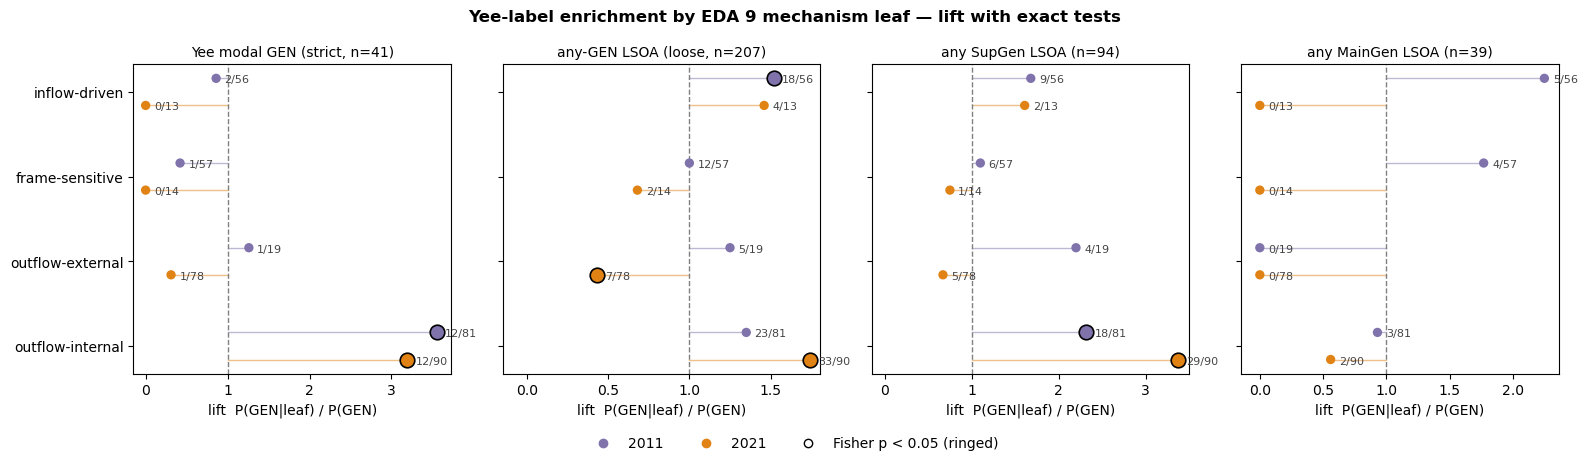

In [6]:
# ── figure: lift dot plot ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

panels = [('gen_modal', 'Yee modal GEN (strict, n=41)'),
          ('has_gen', 'any-GEN LSOA (loose, n=207)'),
          ('any_SupGen', 'any SupGen LSOA (n=94)'),
          ('any_MainGen', 'any MainGen LSOA (n=39)')]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.6), sharey=True)
ypos = {lf: i for i, lf in enumerate(LEAVES[::-1])}
COL = {'11': '#8073ac', '21': '#e08214'}

for ax, (col, title) in zip(axes, panels):
    for yr in ('11', '21'):
        for lf in LEAVES:
            r = enrich(df[f'leaf_{yr}'] == lf, df[col], lf)
            sig = r['fisher_p'] < 0.05
            y = ypos[lf] + (0.16 if yr == '11' else -0.16)
            ax.plot([1, r['lift']], [y, y], color=COL[yr], lw=1, alpha=.5)
            ax.scatter(r['lift'], y, s=110 if sig else 45, color=COL[yr],
                       edgecolors='black' if sig else 'none', lw=1.2, zorder=3)
            ax.annotate(f"{r['GEN']}/{r['n']}", (r['lift'], y), textcoords='offset points',
                        xytext=(6, -3), fontsize=8, color='#444')
    ax.axvline(1, color='grey', lw=1, ls='--')
    ax.set_yticks(range(4)); ax.set_yticklabels(LEAVES[::-1])
    ax.set_title(title, fontsize=10); ax.set_xlabel('lift  P(GEN|leaf) / P(GEN)')
    ax.set_xlim(left=-0.15)
handles = [plt.Line2D([], [], marker='o', ls='', color=COL[y], label=f'20{y}') for y in ('11', '21')]
handles.append(plt.Line2D([], [], marker='o', ls='', mfc='white', mec='black', label='Fisher p < 0.05 (ringed)'))
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Yee-label enrichment by EDA 9 mechanism leaf — lift with exact tests', fontweight='bold')
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(FIG_DIR / 'fig_eda12_lift_by_leaf.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 3. Conclusions — implications for the refined definition

**What EDA 5 called "no association" was pooling artefact plus wrong statistics.** At leaf level, flow mechanisms and Yee's attribute labels are strongly related — just not where the candidate definition predicted.

1. **The refined definition survives, with its scope stated honestly.** *"Persistent, inflow-led, inner-London cascade"* aligns with **mainstream** gentrification (MainGen: Tower Hamlets, Hackney, Southwark) in the **concurrent validation (2011)**, at modest effect size (lift ≈ 1.9–2.3) and low power; the alignment **fails the persistence test (2021)**. Adding *"coincides with attribute ascent"* is supported for this subtype and the concurrent window only.
2. **New finding: the flow lens separates gentrification subtypes by mechanism.** Super-gentrification (Butler & Lees 2006) is invisible to the inflow arm — the ladder ceiling closes it — but appears loudly in the internal-outflow arm, in **both the concurrent and the persistence test** (lift 3.4, q < 1e-9 in 2021). Mainstream gentrification appears in the inflow arm, **concurrently only**. This is a positive contribution the four-way comparison could not see.
3. **The exodus reading is externally corroborated.** The 2021 outflow-external class is GEN-*depleted* under every definition — it is not gentrification relocating outward.
4. **Counter-led remains the anti-gentrification direction**, both years, both aggregations.

**For the deck:** Findings 1 no longer reports a bare null. The line becomes: *the equivalence fails, but the leaf-level test shows the two lenses see the same city — mainstream gentrification is the inflow-led cascade; super-gentrification is the internal displacement cascade; the exodus is neither.*

**Caveats to state:** ladder-ceiling construction (D9–10 cannot be inflow-led); any-LSOA subtype flags are sensitive to MSOA size; n = 39 MainGen base limits power; the persistent-8 include two Hillingdon MSOAs pending a manual check; BH applied within each family of 8 leaf tests.

In [7]:
# ── export ───────────────────────────────────────────────────────────────────
keep = ['msoa11cd', 'msoa_name', 'ladnm', 'Ring', 'Wealth_Decile', 'Wealth_Decile_National',
        'leaf_11', 'leaf_21', 'Genuine_Persistent',
        'yee_modal', 'modal_confidence', 'gen_modal', 'has_gen',
        'any_SupGen', 'any_MainGen', 'any_MargGen',
        'Casc_Inflow_Share_11', 'Casc_Inflow_Share_21', 'Ext_Arm_Share_11', 'Ext_Arm_Share_21']
out = df[keep]
out.to_csv(OUT_DIR / 'eda12_yee_leaf_corroboration_20260705.csv', index=False)
print('exported eda12_yee_leaf_corroboration_20260705.csv', out.shape)

exported eda12_yee_leaf_corroboration_20260705.csv (982, 20)
